In [47]:
pip install xgboost optuna

In [48]:
#importing necessary libraries
import pandas as pd
import numpy as np

#for visualization
import matplotlib.pyplot as plt
import seaborn as sn

#for modelling
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
import optuna
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
# load the dataset
df = pd.read_csv('/content/drive/MyDrive/faults.csv')

# Basic Understanding of data and preprocessing

In [51]:
#to know how big dataset is
df.shape

(1941, 34)

In [52]:
# to know how data looks like
df.sample(5)

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
818,1324,1330,1543653,1543689,145,23,36,16920,108,127,...,0.8333,-0.0884,0.3601,0,0,0,0,1,0,0
1046,1224,1237,812031,812044,137,16,13,14536,81,128,...,0.0000,-0.1711,0.2914,0,0,0,0,0,1,0
1591,721,732,5169308,5169335,226,12,27,24102,84,133,...,0.5926,-0.1668,0.4913,0,0,0,0,0,0,1
569,41,190,508837,508896,5702,216,119,591835,45,126,...,-0.6040,-0.1891,1.0000,0,0,1,0,0,0,0
1032,93,103,4630871,4630888,108,17,17,12886,102,135,...,0.4118,-0.0679,0.2928,0,0,0,0,0,1,0


In [53]:
# to know the columns
df.columns

Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'],
      dtype='object')

In [54]:
# here the last 7 columns represent fault classes so i will convert the 7 columns into a single one and remove the unnecessary columns.
# Check if any row has multiple fault labels
target_columns = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

def check_multilabel(df, target_columns):
    multilabel_rows = df[target_columns].sum(axis=1) > 1
    if multilabel_rows.any():
        print("This is a multi-label classification problem.")
        print(f"Total multi-label rows: {multilabel_rows.sum()}")
    else:
        print("This is a multi-class classification problem.")

check_multilabel(df,target_columns)

This is a multi-class classification problem.


In [55]:
#converting into single column
df['Fault_type'] = df[target_columns].idxmax(axis = 1)
df=df.drop(target_columns, axis=1)
df.sample(5)
print(df.shape)

(1941, 28)


In [56]:
# to know datatype of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empt

In [57]:
# to check nunique values
df.nunique()

,0
X_Minimum,962
X_Maximum,994
Y_Minimum,1939
Y_Maximum,1940
Pixels_Areas,920
X_Perimeter,399
Y_Perimeter,317
Sum_of_Luminosity,1909
Minimum_of_Luminosity,161
Maximum_of_Luminosity,100


In [58]:
print(df['Outside_Global_Index'].unique())
print(df['Steel_Plate_Thickness'].unique())

[1.  0.5 0. ]
[ 80 100 290 185  40 150 200  50  70 250  60  69 120 211 143 220 175 125
  90  85 300 180 130 140]


In [59]:
# types_of_steel_columns are categorical which is onehotencoded
# Rename multiple columns
df.rename(columns={'TypeOfSteel_A300': 'A300', 'TypeOfSteel_A400': 'A400'}, inplace=True)

#converting the 2 type of steel column into a single one
type_of_steel = ['A300','A400']
df['Steel_type'] = df[type_of_steel].idxmax(axis = 1)
df=df.drop(type_of_steel, axis=1)
df.shape

(1941, 27)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  Steel_Plate_Thickness  1941 non-null   int64  
 12  Edges_Index            1941 non-null   float64
 13  Empty_Index            1941 non-null   float64
 14  Square_Index           1941 non-null   float64
 15  Outs

In [61]:
# to know duplicate values
df.duplicated().sum()

np.int64(0)

In [62]:
# to check missing values
df.isnull().sum()/len(df)*100

,0
X_Minimum,0.0
X_Maximum,0.0
Y_Minimum,0.0
Y_Maximum,0.0
Pixels_Areas,0.0
X_Perimeter,0.0
Y_Perimeter,0.0
Sum_of_Luminosity,0.0
Minimum_of_Luminosity,0.0
Maximum_of_Luminosity,0.0


### there is no missing values

In [63]:
# to separate categorical and numerical
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# EDA

In [64]:
# to know how data looks mathematically
df.describe()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.033361,0.610529,0.813472,0.575734,2.492388,1.335686,1.403271,0.083288,-0.131305,0.585420
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.058961,0.243277,0.234274,0.482352,0.788930,0.481612,0.454345,0.500868,0.148767,0.339452
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,0.001500,0.014400,0.048400,0.000000,0.301000,0.301000,0.000000,-0.991000,-0.998900,0.119000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,0.006600,0.411800,0.596800,0.000000,1.924300,1.000000,1.079200,-0.333300,-0.195000,0.248200
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.010100,0.636400,0.947400,1.000000,2.240600,1.176100,1.322200,0.095200,-0.133000,0.506300
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.023500,0.800000,1.000000,1.000000,2.914900,1.518500,1.732400,0.511600,-0.066600,0.999800
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.875900,1.000000,1.000000,1.000000,5.183700,3.074100,4.258700,0.991700,0.642100,1.000000


In [65]:
#to check skewness
df.select_dtypes(include=['float64', 'int64']).skew()

,0
X_Minimum,0.500897
X_Maximum,0.524210
Y_Minimum,2.811213
Y_Maximum,2.811169
Pixels_Areas,14.083822
X_Perimeter,21.539451
Y_Perimeter,39.293158
Sum_of_Luminosity,7.730720
Minimum_of_Luminosity,-0.107098
Maximum_of_Luminosity,1.287035


In [66]:
# Apply transformations
df['Pixels_Areas'] = np.log1p(df['Pixels_Areas'])
df['X_Perimeter'] = np.log1p(df['X_Perimeter'])
df['Y_Perimeter'] = np.log1p(df['Y_Perimeter'])
df['Sum_of_Luminosity'] = np.log1p(df['Sum_of_Luminosity'])
df['Outside_X_Index'] = np.log1p(df['Outside_X_Index'])
df['Outside_Global_Index'] = np.log1p(df['Outside_Global_Index'])
df['Steel_Plate_Thickness'] = np.log1p(df['Steel_Plate_Thickness'])

In [67]:
df.select_dtypes(include=['float64', 'int64']).skew()

,0
X_Minimum,0.500897
X_Maximum,0.524210
Y_Minimum,2.811213
Y_Maximum,2.811169
Pixels_Areas,0.767502
X_Perimeter,0.880018
Y_Perimeter,0.706116
Sum_of_Luminosity,0.787480
Minimum_of_Luminosity,-0.107098
Maximum_of_Luminosity,1.287035


In [68]:
# to check outliers
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    outliers = series[(series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)]
    return outliers

In [69]:
for i in num_cols:
    outliers = detect_outliers_iqr(df[i])
    print(f"Number of outliers in {i}: {len(outliers)}")

Number of outliers in X_Minimum: 0
Number of outliers in X_Maximum: 0
Number of outliers in Y_Minimum: 81
Number of outliers in Y_Maximum: 81
Number of outliers in Pixels_Areas: 4
Number of outliers in X_Perimeter: 7
Number of outliers in Y_Perimeter: 1
Number of outliers in Sum_of_Luminosity: 25
Number of outliers in Minimum_of_Luminosity: 20
Number of outliers in Maximum_of_Luminosity: 146
Number of outliers in Length_of_Conveyer: 0
Number of outliers in Steel_Plate_Thickness: 47
Number of outliers in Edges_Index: 0
Number of outliers in Empty_Index: 20
Number of outliers in Square_Index: 0
Number of outliers in Outside_X_Index: 370
Number of outliers in Edges_X_Index: 0
Number of outliers in Edges_Y_Index: 0
Number of outliers in Outside_Global_Index: 0
Number of outliers in LogOfAreas: 6
Number of outliers in Log_X_Index: 34
Number of outliers in Log_Y_Index: 4
Number of outliers in Orientation_Index: 0
Number of outliers in Luminosity_Index: 134
Number of outliers in SigmoidOfArea

# some features have outliers so outliers robust algorithms i will use

In [70]:
# to know distribution of class
df['Fault_type'].value_counts()/len(df)*100

,count
Fault_type,
Other_Faults,34.672849
Bumps,20.710974
K_Scatch,20.144256
Z_Scratch,9.788769
Pastry,8.140134
Stains,3.709428
Dirtiness,2.833591


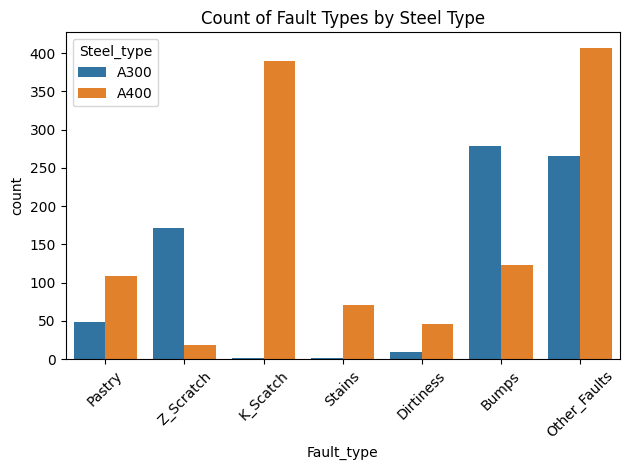

In [71]:
sn.countplot(x='Fault_type', hue='Steel_type', data=df)
plt.title('Count of Fault Types by Steel Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# the class is imbalanced which is needed to be taken care of

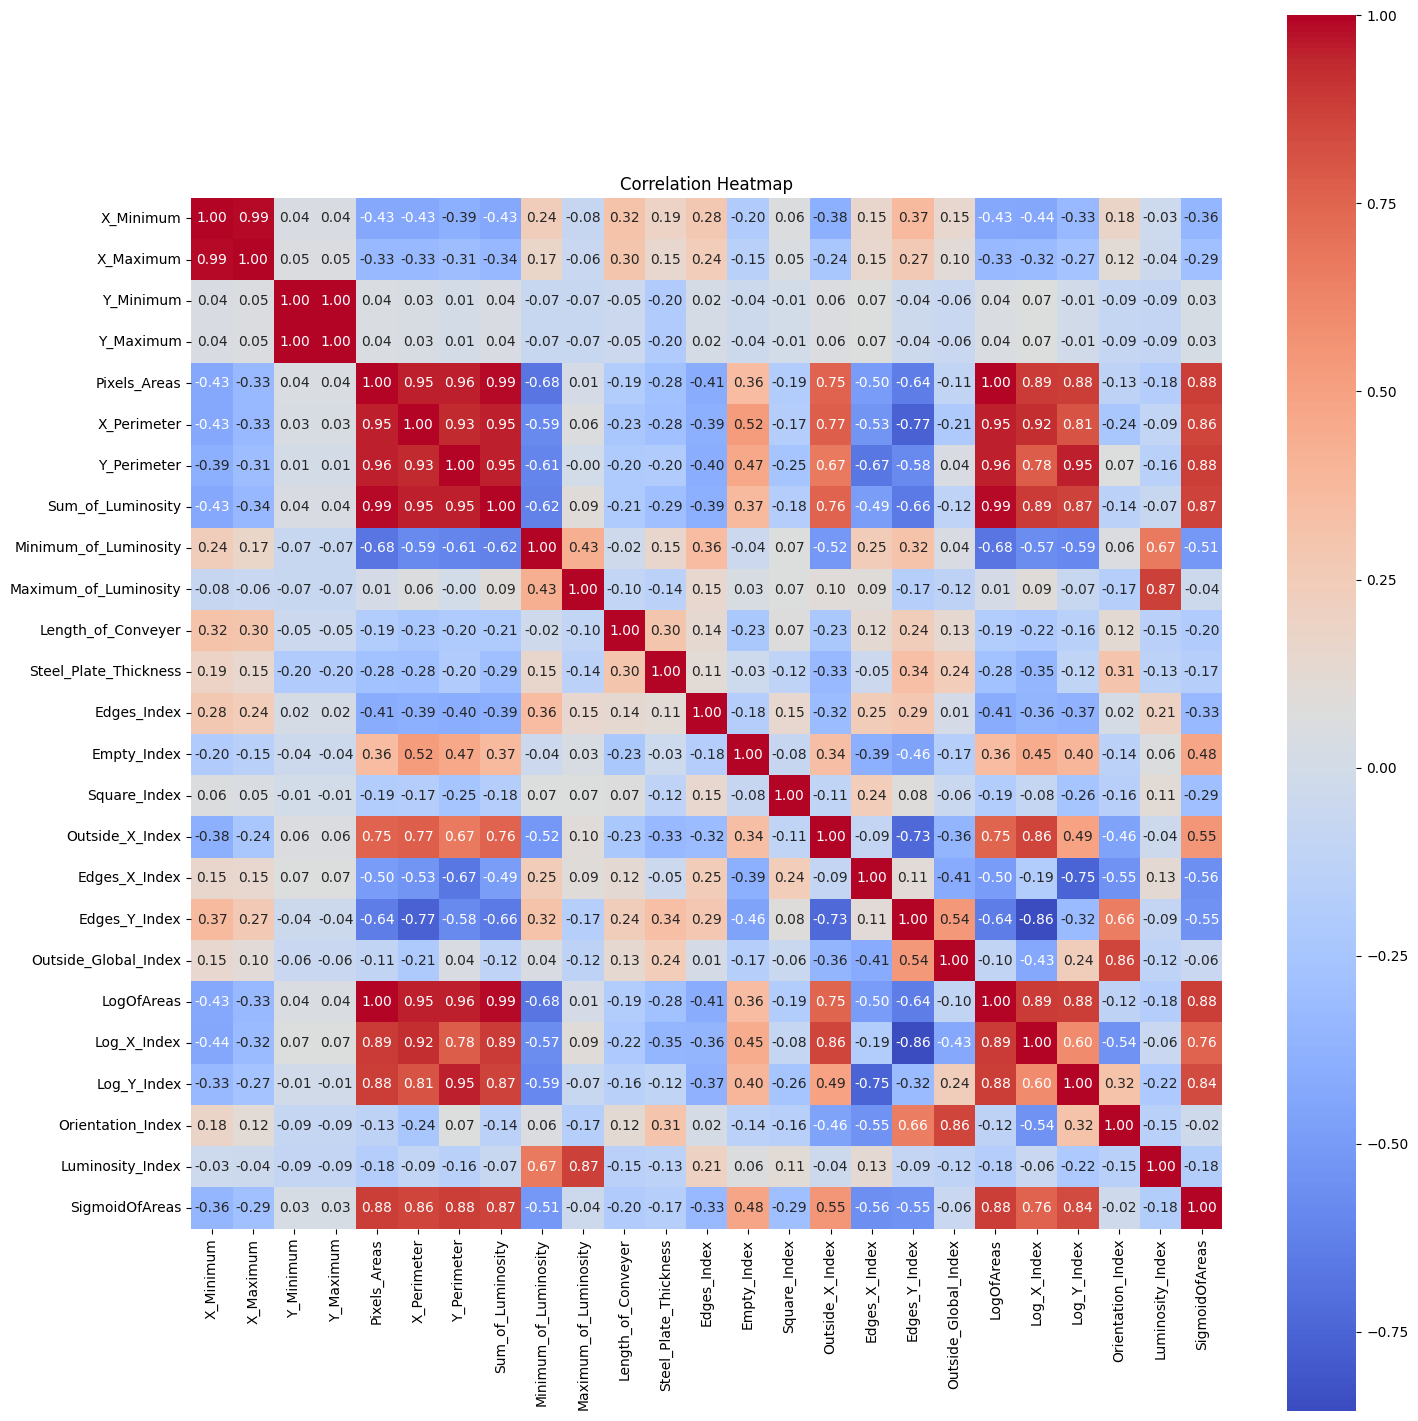

In [72]:
# correlation matrix
corr = df[num_cols].corr()
plt.figure(figsize=(15, 15))
sn.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


#### feature are highly correlated but i don't know which to remove because i don't have domain knowledge. so i am keeping it as it is.

#### so i am going to use tree based models

# Model training, evaluation, saving

In [73]:
df.shape

(1941, 27)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   float64
 5   X_Perimeter            1941 non-null   float64
 6   Y_Perimeter            1941 non-null   float64
 7   Sum_of_Luminosity      1941 non-null   float64
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  Steel_Plate_Thickness  1941 non-null   float64
 12  Edges_Index            1941 non-null   float64
 13  Empty_Index            1941 non-null   float64
 14  Square_Index           1941 non-null   float64
 15  Outs

In [75]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Fault_type'] = le.fit_transform(df['Fault_type'])
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

df['Steel_type'] = le.fit_transform(df['Steel_type'])

{'Bumps': 0, 'Dirtiness': 1, 'K_Scatch': 2, 'Other_Faults': 3, 'Pastry': 4, 'Stains': 5, 'Z_Scratch': 6}


In [76]:
# splitting features and target
X = df.drop('Fault_type', axis=1)
y = df['Fault_type']

# splitting for traing and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
# creating model objects
classifiers = {
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "SVM": SVC(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(random_state=42, scale_pos_weight=1, verbosity = 0)
}

# training and evaluating
for name, model in classifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"{name} - F1 Score: {f1:.4f}")

Decision Tree - F1 Score: 0.7134
Random Forest - F1 Score: 0.7672
SVM - F1 Score: 0.2410
XGBoost - F1 Score: 0.7643


In [78]:
# training with kfold cv

classifiers = {
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(random_state=42, scale_pos_weight=1, verbosity = 0)
}


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in classifiers.items():
    cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='f1_weighted')
    print(f"{name} - Mean F1 Score: {np.mean(cv_scores):.4f}")
    print(f"{name} - Standard Deviation: {np.std(cv_scores):.4f}")
    print("-" * 50)

Decision Tree - Mean F1 Score: 0.7066
Decision Tree - Standard Deviation: 0.0098
--------------------------------------------------
Random Forest - Mean F1 Score: 0.7700
Random Forest - Standard Deviation: 0.0139
--------------------------------------------------
XGBoost - Mean F1 Score: 0.8050
XGBoost - Standard Deviation: 0.0114
--------------------------------------------------


In [79]:
# hyperparameter tuning using optuna

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
num_classes = len(np.unique(y))

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 10),
        'random_state': 42,
        'verbosity': 0,
        'use_label_encoder': False,
        'n_jobs': -1,
        'objective': 'multi:softmax',
        'num_class': num_classes,
        'eval_metric': 'mlogloss'
    }

    model = XGBClassifier(**params)
    scores = cross_val_score(model, X, y, cv=kfold, scoring='f1_weighted')
    return np.mean(scores)

# Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print("Best trial:")
print(study.best_trial)
print("Best parameters:")
print(study.best_params)

[I 2025-05-12 22:00:28,037] A new study created in memory with name: no-name-87fb1b7e-a9c6-4d73-9102-2fd629ce4c8e
[I 2025-05-12 22:00:31,016] Trial 0 finished with value: 0.7563237773061171 and parameters: {'n_estimators': 155, 'max_depth': 4, 'learning_rate': 0.12571384775072103, 'subsample': 0.7892119196330382, 'colsample_bytree': 0.7555260904712386, 'gamma': 1.2151369979008337, 'reg_alpha': 4.22690259905229, 'reg_lambda': 0.3043296668947615, 'scale_pos_weight': 9.695319150006883}. Best is trial 0 with value: 0.7563237773061171.
[I 2025-05-12 22:00:34,243] Trial 1 finished with value: 0.7584915324811451 and parameters: {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.07083850176691221, 'subsample': 0.64629133772161, 'colsample_bytree': 0.6614902650368732, 'gamma': 1.8987444355363348, 'reg_alpha': 0.9588502391938541, 'reg_lambda': 3.9605817387429627, 'scale_pos_weight': 1.3215087921115387}. Best is trial 1 with value: 0.7584915324811451.
[I 2025-05-12 22:00:35,790] Trial 2 fin

Best trial:
FrozenTrial(number=23, state=1, values=[0.8050998861118327], datetime_start=datetime.datetime(2025, 5, 12, 22, 4, 47, 677770), datetime_complete=datetime.datetime(2025, 5, 12, 22, 4, 56, 682867), params={'n_estimators': 254, 'max_depth': 7, 'learning_rate': 0.16129459664295961, 'subsample': 0.9984272962837657, 'colsample_bytree': 0.59129730210573, 'gamma': 0.17628935028753728, 'reg_alpha': 0.04435165436031742, 'reg_lambda': 3.256959700393385, 'scale_pos_weight': 5.112699618158279}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=300, log=False, low=50, step=1), 'max_depth': IntDistribution(high=15, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=False, low=0.01, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'gamma': FloatDistribution(high=5.0, log=False, low=0.0, step=No

In [80]:
# final training on best parameters
best_params = study.best_params
num_classes = len(np.unique(y))
model = XGBClassifier(**best_params, objective='multi:softmax', num_class=num_classes, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"XGBoost (best parameters) - F1 Score: {f1:.4f}")
print(classification_report(y_test,y_pred))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:08:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost (best parameters) - F1 Score: 0.7865
              precision    recall  f1-score   support

           0       0.62      0.62      0.62        72
           1       0.75      0.75      0.75         8
           2       0.95      0.96      0.96        83
           3       0.73      0.75      0.74       143
           4       0.65      0.59      0.62        29
           5       1.00      0.92      0.96        13
           6       0.97      0.95      0.96        41

    accuracy                           0.79       389
   macro avg       0.81      0.79      0.80       389
weighted avg       0.79      0.79      0.79       389



In [81]:
import joblib

joblib.dump(model, 'xgboost_model.pkl')
joblib.dump(model, '/content/drive/MyDrive/xgboost_model.pkl')


['/content/drive/MyDrive/xgboost_model.pkl']